In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization

import sklearn
import statistics

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

import matplotlib.pyplot as plt

from sklearn.svm import SVR 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_score

file_path = 'Cafe_2022_for_ANN.csv'
df = pd.read_csv(file_path)
df.set_index('ts', inplace=True)
display(df)


,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [2]:
df.index = pd.to_datetime(df.index)

mask = (df.index.month >= 7) & (df.index.month < 8)  # July / 1 month

df_july = df[mask]

In [3]:
x = df_july.drop('kW',axis = 1)
y = df_july.kW

#split into training, testing data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
Fit = scaler.fit(x_train)

X_train_scaled = Fit.transform(x_train)
X_test_scaled = Fit.transform(x_test)

# Cross Validation
# Input parameters ranges to cross validation 
gamma_range = [0.1, 0.01, 0.001, 0.0001]
epsilon_range = [x * 0.1 for x in range(0, 2)]
C_range = range(1, 2500, 500)

tuned_parameters = [{
    'kernel': ['rbf'],
    'C': C_range,
    'gamma': gamma_range,
    'epsilon': epsilon_range}]

#Search for best parameters w/ cross validation
svr = GridSearchCV(SVR(C=2000, gamma=0.01), param_grid = tuned_parameters, verbose = 0)

modelSVR = svr.fit(X_train_scaled, np.ravel(y_train))

print(svr.best_params_)

{'C': 501, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}


In [4]:
# predict
y_predict = modelSVR.predict(X_test_scaled)

print("The train score R2 for SVR: ", svr.score(X_train_scaled, y_train) , "\n")

print("The test score R2 for SVR: ", svr.score(X_test_scaled, y_test))
# print("SVR root mean squared error: %.2f"
#  % m.sqrt(np.mean((np.array(y_test) - svr.predict(X_test)) ** 2)))
print("SVR root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(y_test, y_predict, squared=False))

# absolute_percentage_errors = np.abs((y_test - y_predict) / y_test)
# absolute_percentage_errors = absolute_percentage_errors[~np.isnan(absolute_percentage_errors)]
# mape = np.mean(absolute_percentage_errors) * 100
# print("MAPE: ", mape)

print("SVR CV value: ", (statistics.stdev(y_predict/statistics.mean(y_predict))*100))

The train score R2 for SVR:  0.8824078150035809 

The test score R2 for SVR:  0.8288706426649137
SVR root mean squared error: 3.72
SVR CV value:  27.097508647394005


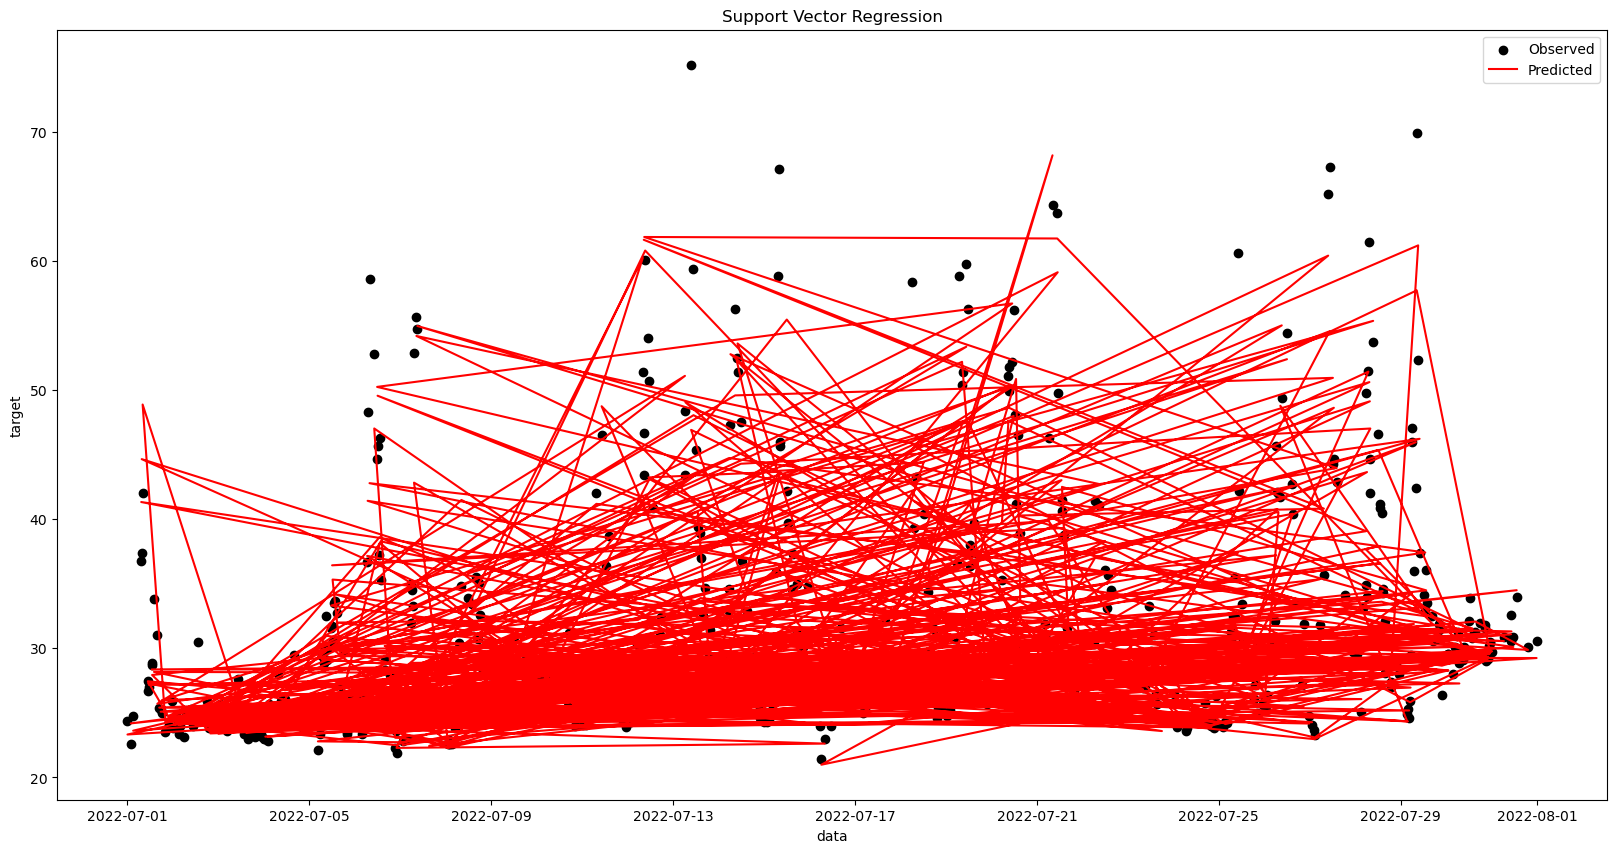

Text(0.5, 1.0, 'Predicted vs Actual Energy Use: $Y_i$ vs $\\hat{Y}_i$')

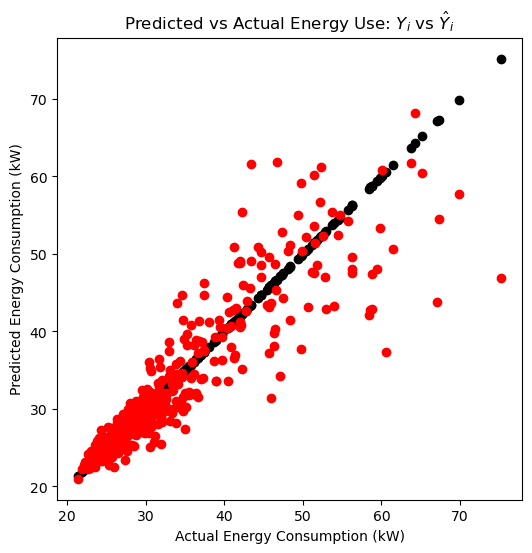

In [5]:
# Visualize Data
# Plot observed and predicted energy values (actual data points vs svm)
fig,ax = plt.subplots(1, 1,figsize=(20,10))
plt.scatter(x_test.index, y_test, c='k', label='Observed')
plt.plot(x_test.index, y_predict, c='r', label='Predicted')
plt.xlabel('data')
plt.ylabel('target')
plt.title('Support Vector Regression')
plt.legend()
plt.show()

# Plot Observed vs Predicted (line of best fit chart)
fig = plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, c='k')
plt.scatter(y_test, y_predict, c='r')
plt.xlabel('Actual Energy Consumption (kW)')
plt.ylabel("Predicted Energy Consumption (kW)")
plt.title("Predicted vs Actual Energy Use: $Y_i$ vs $\hat{Y}_i$")

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
# Error Evaluation 
# Training error 

# print("Train Data")
# print("R^2:", r2_score(y_train, y_predict_train))
# print("MSE:", mean_squared_error(y_train, y_predict_train))
# print("Root MSE:", np.sqrt(mean_squared_error(y_train, y_predict_train)))
# print("MAE:", mean_absolute_error(y_train, y_predict_train))
# print("MAPE: %", mean_absolute_percentage_error(y_train ,y_predict_train))

# print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y_test, y_predict))
print("MSE:", mean_squared_error(y_test, y_predict))
print("Root MSE:", np.sqrt(mean_squared_error(y_test, y_predict)))
print("MAE:", mean_absolute_error(y_test, y_predict))
print("MAPE: %", mean_absolute_percentage_error(y_test, y_predict))

Test Data
R^2: 0.8288706426649137
MSE: 13.853552711937589
Root MSE: 3.722036097613454
MAE: 1.985215824388463
MAPE: % 0.053187511178755656
